In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from msi.utils import preprocessing, plotting, input_output
from msfm.utils import prior, parameters, files, logger, cross_statistics, scales, observation, power_spectra

# configuration

In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")

n_side = conf["analysis"]["n_side"]
n_pix = conf["analysis"]["n_pix"]
data_vec_pix = files.load_pixel_file(conf)[0]
hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

24-07-25 01:39:27     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 


In [4]:
# # lensing only
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# with_cross_probe = False

In [5]:
# clustering only
params = ["Om", "s8", "w0", "bg", "n_bg"]
with_lensing = False
with_clustering = True
with_cross_z = True
with_cross_probe = False

In [6]:
# # combined probes
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# with_lensing = True
# with_clustering = True
# with_cross_z = True
# with_cross_probe = True

In [7]:
bin_indices, bin_names = cross_statistics.get_cross_bin_indices(
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=with_cross_probe,
)

In [8]:
# smooth differently
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")

base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

In [9]:
apply_log = False
standardize = False
# standardize = True
pca_components = None
# pca_components = 32
# pca_components = 16

# power spectrum scale cuts (in ell)
n_bins = 33

l_mins = 8 * [30]
# l_mins = 8 * [None]

def angle_to_ell(angles):
    return list(scales.angle_to_ell(np.array(angles), arcmin=True))

# 6 and 16 Mpc/h
l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])
# l_maxs = 8 * [None]

mpc_fwhm = "None"
label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components},fwhm={mpc_fwhm},standard={standardize}"

# load the CosmoGrid power spectra

24-07-25 01:39:28 preprocessin INF   Applying scale cuts to the raw Cls 
24-07-25 01:39:28 preprocessin INF   l_mins = [30, 30, 30, 30, 30, 30, 30, 30] 
24-07-25 01:39:28 preprocessin INF   l_maxs = [488.6877828054298, 715.2317880794702, 964.2857142857142, 1148.936170212766, 165.89861751152074, 242.69662921348313, 316.7155425219941, 378.94736842105266] 
24-07-25 01:39:36 input_output INF   Array shapes: 
24-07-25 01:39:36 input_output INF   fiducial/i_example = (40000,) 
24-07-25 01:39:36 input_output INF   fiducial/i_noise   = (40000,) 
24-07-25 01:39:36 input_output INF   fiducial/cls/binned = (40000, 32, 36) 
24-07-25 01:39:36 input_output INF   fiducial/cls/bin_edges = (33, 36) 
24-07-25 01:39:36 input_output INF   grid/cosmo         = (2500, 240, 12) 
24-07-25 01:39:36 input_output INF   grid/i_example     = (2500, 240) 
24-07-25 01:39:36 input_output INF   grid/i_noise       = (2500, 240) 
24-07-25 01:39:36 input_output INF   grid/i_sobol       = (2500, 240) 
24-07-25 01:39:40 in

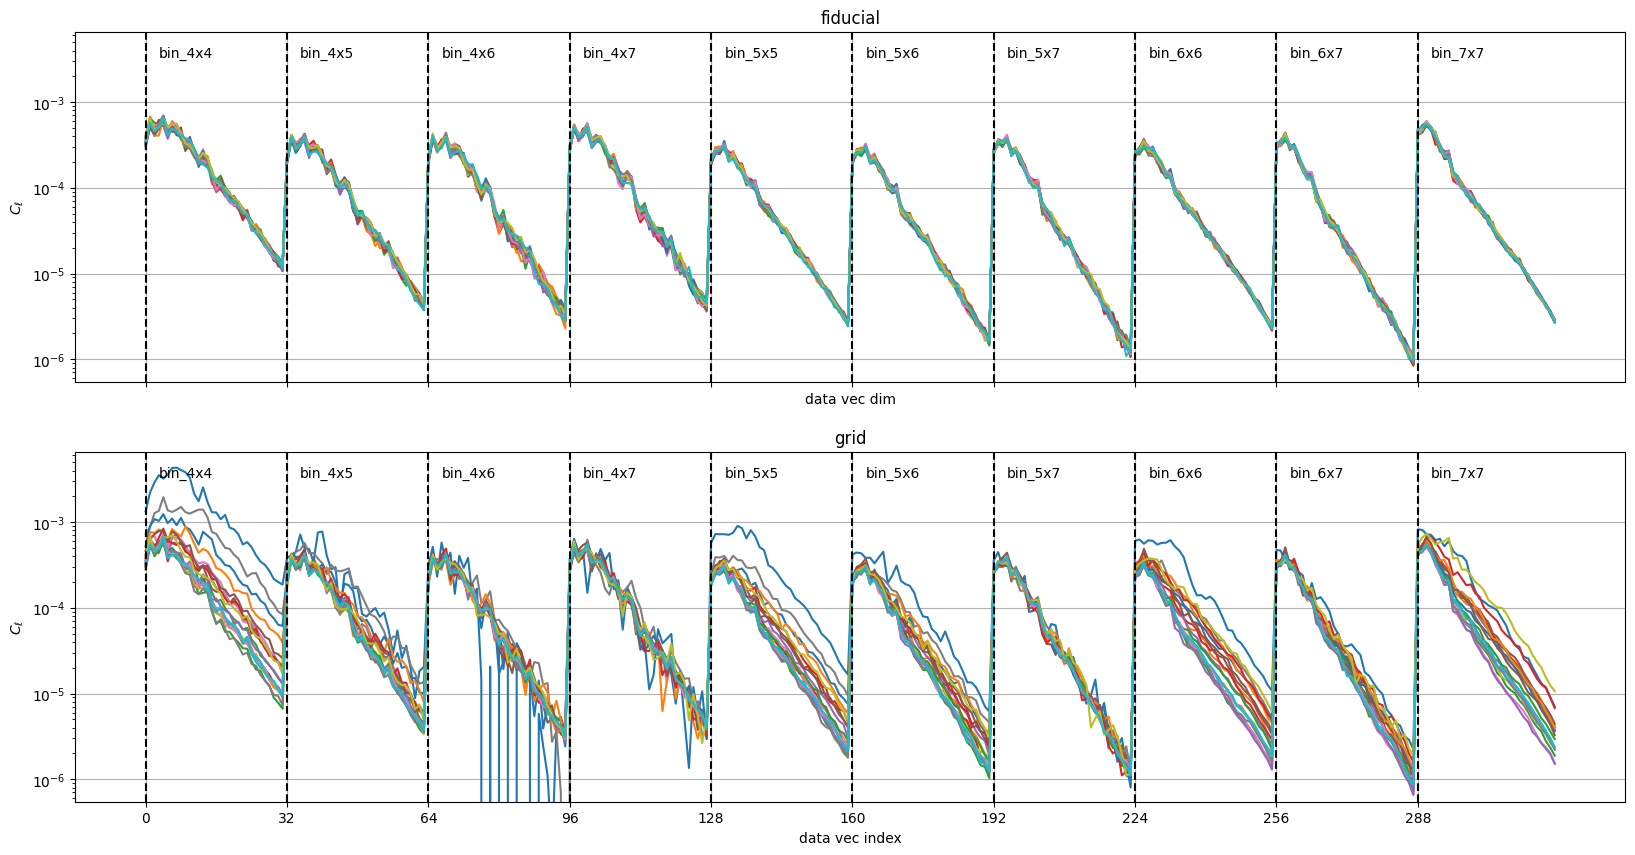

In [10]:
summary = "cls"
# summary = "peaks"

fidu_summs, grid_summs, grid_cosmos, grid_i_sobols, file_dict, scaler, pca = preprocessing.get_reshaped_human_summaries(
    base_dir, 
    summary, 
    # file
    file_label=None,
    # configuration
    conf=conf, 
    params=params,
    concat_example_dim=True,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=with_cross_probe,
    # power spectra: scales
    l_mins=l_mins,
    l_maxs=l_maxs,
    n_bins=n_bins,
    # only_keep_bins=keep_bins,
    # peaks: scales
    scale_indices=None,
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    pca_components=pca_components,
)

out_dir = os.path.join(out_dir, summary) if (os.path.basename(out_dir) != summary) else out_dir
os.makedirs(out_dir, exist_ok=True)

In [11]:
# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(fidu_summs[0], label="raw CosmoGrid")
# ax.set(xscale="linear", yscale="log")
# ax.legend(loc="best")

In [12]:
# fidu_cl_file = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias/cls/fiducial_cls.h5"

# with h5py.File(fidu_cl_file, "r") as f:
#     cls_raw = f["cls/raw"][0,...,bin_indices]
# print(cls_raw.shape)

# cls_concat = np.concatenate([cls_raw[..., i] for i in range(cls_raw.shape[-1])], axis=-1)
# print(cls_concat.shape)

# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(cls_concat, label="raw CosmoGrid")
# ax.set(xscale="linear", yscale="log")
# ax.legend(loc="best")

In [13]:
# # binned here
# cls_binned, _ = power_spectra.bin_cls(
#     cls_raw,
#     # clustering only
#     # l_mins=l_mins[4:],
#     # l_maxs=l_maxs[4:],
#     # l_mins=l_mins[:4],
#     # l_maxs=l_maxs[:4],
#     n_bins=n_bins,
#     n_side=n_side,
#     with_cross=True,
#     per_cross_binning=True,
# )
# # cls_binned = cls_binned[..., bin_indices]
# cls_binned = np.concatenate([cls_binned[..., i] for i in range(cls_raw.shape[-1])], axis=-1)

# # original
# cls_binned_og = file_dict["fiducial/cls/binned"][0]
# cls_binned_og = cls_binned_og[..., bin_indices]
# cls_binned_og = np.concatenate([cls_binned_og[..., i] for i in range(cls_binned_og.shape[-1])], axis=-1)

# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(cls_binned, label="binned CosmoGrid (new pipeline)")
# ax.plot(cls_binned_og, label="binned CosmoGrid (as loaded)")
# ax.set(xscale="linear", yscale="log")
# ax.legend(loc="best")

# load the external mock

24-07-25 01:46:28     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
24-07-25 01:46:28     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 


[None, None]

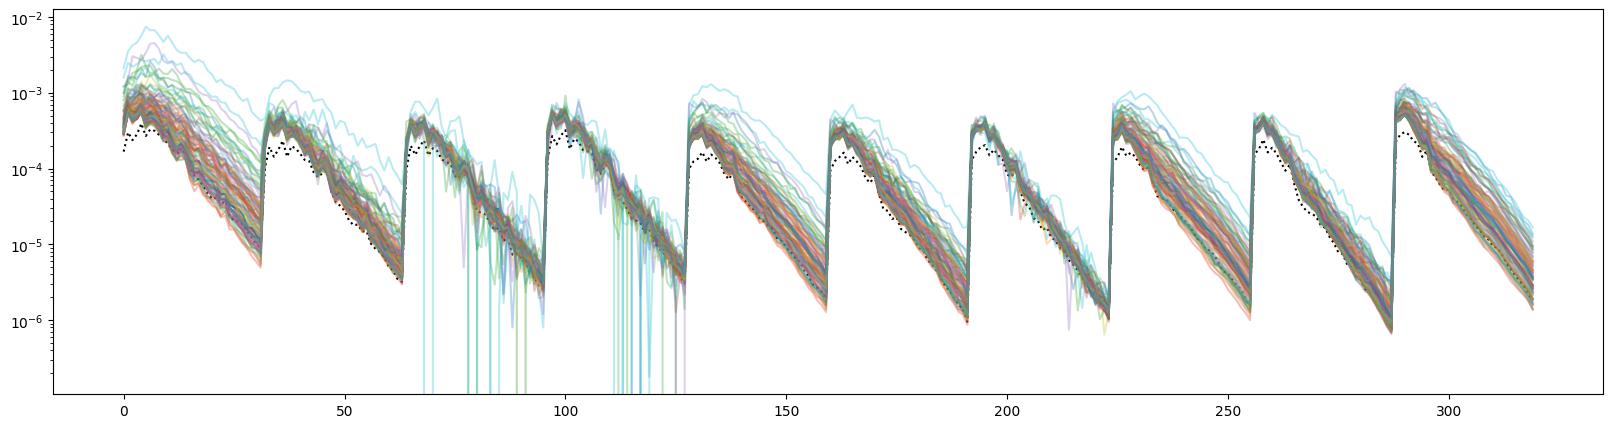

In [19]:
# obs_file = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_Buzzard_mock.h5"
# obs_label = f"Buzzard"

obs_file = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_Cardinal_mock.h5"
obs_label = f"Cardinal"

with h5py.File(obs_file, "r") as f:
    gc_map = []
    for i in range(1,5):
        gc_map.append(f[f"maglim/galaxy_counts_bin{i}"][:])
    gc_map = np.stack(gc_map, axis=-1)
    
obs_dv = observation.forward_model_observation_map(
    wl_gamma_map=np.zeros((hp.nside2npix(512),4,2)),
    gc_count_map=gc_map,
    conf=conf,
    apply_norm=True,
    with_padding=True,
    nest=False,
)

obs_map = np.zeros((n_pix, obs_dv.shape[-1]))
obs_map[data_vec_pix] = obs_dv

# for i in range(obs_map.shape[-1]):
#     hp.mollview(obs_map[:,i], title=f"bin {i}", nest=True)
#     hp.gnomview(obs_map[:,i], title=f"bin {i}", rot=(90, -30, 0), nest=True)

obs_alm = power_spectra.get_alms(obs_map, nest=True, datapath=hp_datapath)
obs_cl = power_spectra.get_cls(obs_alm, with_cross=True)
obs_cl_raw = obs_cl.copy()

# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(obs_cl, label=obs_label)
# ax.plot(cls_raw, label="raw CosmoGrid")
# ax.set(xscale="linear", yscale="log")
# ax.legend(loc="best")

obs_cl, _ = power_spectra.bin_cls(
    obs_cl,
    l_mins=l_mins,
    # l_mins=8*[0],
    l_maxs=l_maxs,
    n_bins=n_bins,
    n_side=n_side,
    with_cross=True,
    per_cross_binning=True,
)

# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(obs_cl)
# ax.set(xscale="linear", yscale="log")

# select the right cross tomographic bins
obs_cl = obs_cl[...,bin_indices]
obs_cl_raw = obs_cl_raw[...,bin_indices]

# concatenate the bins along the last axis
obs_cl = np.concatenate([obs_cl[..., i] for i in range(obs_cl.shape[-1])], axis=-1)
obs_cl_raw = np.concatenate([obs_cl_raw[..., i] for i in range(obs_cl_raw.shape[-1])], axis=-1)

fig, ax = plt.subplots(figsize=(20,5))
ax.plot(obs_cl, label=obs_label, linestyle=":", color="k")
ax.plot(fidu_summs[0], label="raw CosmoGrid (fiducial)")
ax.plot(grid_summs[np.random.randint(0,600_000,100)].T, label="raw CosmoGrid (grid)", alpha=0.3)
# ax.plot(cls_raw, label="raw CosmoGrid")
ax.set(xscale="linear", yscale="log")
# ax.legend(loc="best")

# obs_pca, _, _ = preprocessing.preprocess_human_summaries(
#     obs_cl[np.newaxis], 
#     apply_log=apply_log,
#     standardize=standardize,
#     pca_components=pca_components,
#     scaler=scaler,
#     pca=pca,
# )
# obs_pca = np.squeeze(obs_pca)

# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(obs_pca, label=obs_label)
# ax.plot(obs_fiducial, label="fiducial")
# ax.set(xscale="linear", yscale="linear")
# ax.legend()

# obs_summ = obs_pca
# obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": 1.5, "n_bg": 0.5}

# print(obs_summ)

(40000, 1536, 36)
(1536, 10)
(2500, 240, 1536, 36)
(100, 1536, 10)


[None, None, (1e-08, 0.01)]

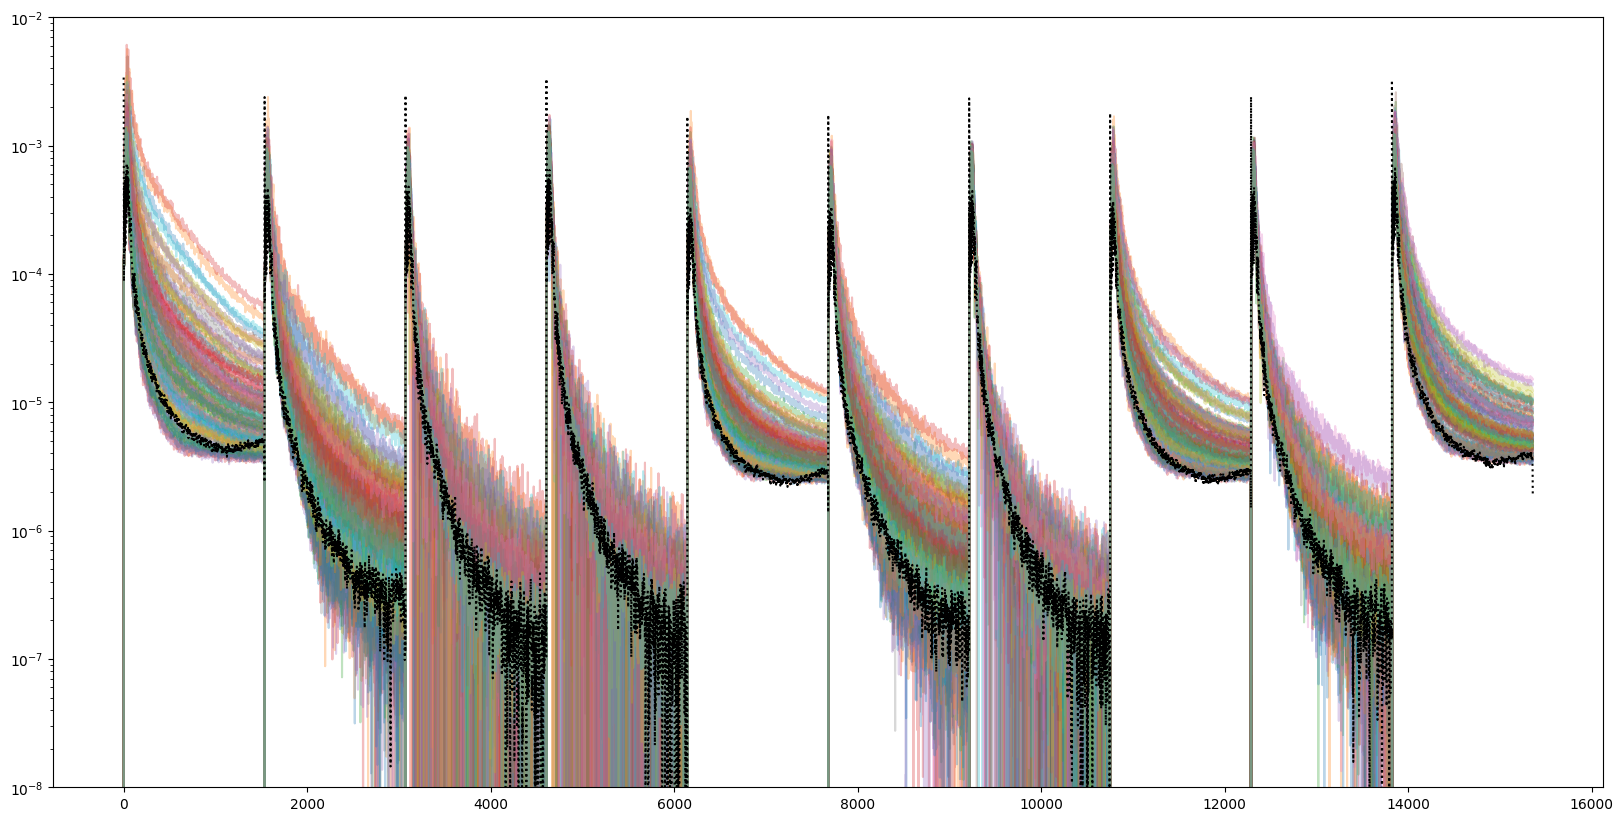

In [18]:
fidu_cl_file = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias/cls/fiducial_cls.h5"
grid_cl_file = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias/cls/grid_cls.h5"

with h5py.File(fidu_cl_file, "r") as f:
    print(f["cls/raw"].shape)
    fidu_cls_raw = f["cls/raw"][0,...,bin_indices]
print(fidu_cls_raw.shape)

with h5py.File(grid_cl_file, "r") as f:
    print(f["cls/raw"].shape)
    grid_cls_raw = f["cls/raw"][:100,0,...,bin_indices]
print(grid_cls_raw.shape)

fidu_cls_concat = np.concatenate([fidu_cls_raw[..., i] for i in range(fidu_cls_raw.shape[-1])], axis=-1)
grid_cls_concat = np.concatenate([grid_cls_raw[..., i] for i in range(grid_cls_raw.shape[-1])], axis=-1)

fig, ax = plt.subplots(figsize=(20,10))
# ax.plot(fidu_cls_concat, label="raw CosmoGrid (fiducial)")
ax.plot(grid_cls_concat.T, label="raw CosmoGrid (grid)", alpha=0.3)
ax.plot(obs_cl_raw, label="mock observation", linestyle=":", color="k")
ax.set(xscale="linear", yscale="log",ylim=(1e-8,1e-2))
# ax.legend(loc="best")